# Siparişler - `review_score` için Çok Değişkenli Regresyon

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Import modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

⚠️ Devam etmeden önce:\n- 💾 Önceki birimin Orders çözümünü indirin\n- 👥 `order_solution.py` içeriğini `olist/order.py` dosyanıza yapıştırın

⚠️ `olist` deposundaki `order.py` dosyasına yaptığınız kod değişikliklerini commit etmeyi unutmayın!

👇 Önce `orders` veri setini içe aktarın

In [ ]:
from olist.order import Order
orders = Order().get_training_data(with_distance_seller_customer=True)

Önceki analizimizi hatırlayalım:\n\nAşağıdaki korelasyon matrisine göre 👇 `review_score` çoğunlukla iki özellik ile ilişkilidir: `wait_time` ve `delay_vs_expected`. Ancak bu iki özellik birbirleriyle de güçlü bir şekilde ilişkilidir.\n\nBu alıştırmada, bir özelliğin etkisini ayırt etmek için `statsmodels` kullanacağız; **diğer özellikleri sabit tutarak** inceleyeceğiz.

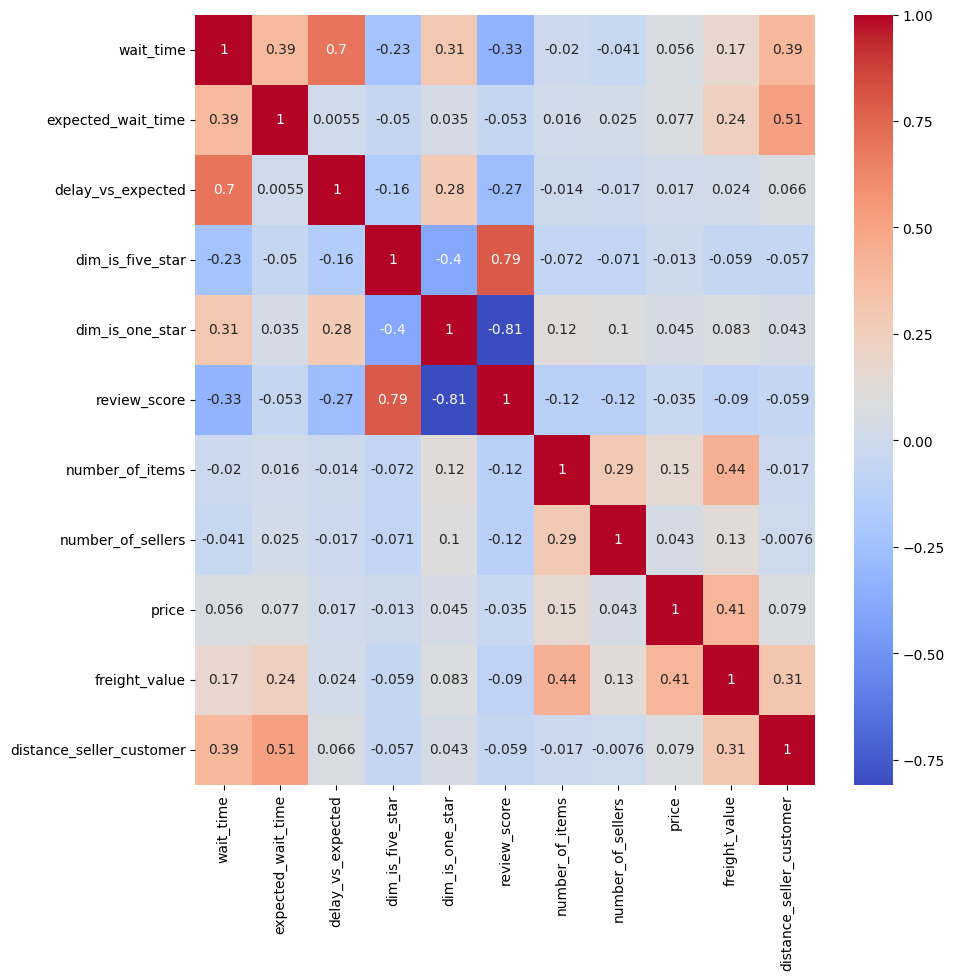

In [ ]:
plt.figure(figsize = (10, 10))

sns.heatmap(
    orders.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,
    annot_kws={"size": 10}
);

## 1 - Tek Değişkenli Regresyon

❓ Hızlıca oluşturmak için `statsmodels.formula.api` içindeki [statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.formula.api.ols.html) kütüphanesini kullanın:\n - `model1`: `review_score` üzerindeki `wait_time` için bir OLS regresyonu\n - `model2`: `review_score` üzerindeki `delay_vs_expected` için bir OLS regresyonu\n\nHer model için `summary` tablosunu yazdırın ve sonuçları yorumlayın:\n - Bu sonuçların seaborn `regplot` ile nasıl uyumlu olduğunu anlayın\n - Regresyon performans metriği `R-squared`, `regresyon katsayıları`, `t-değerleri`, `p-değerleri` ve `%95 güven aralıklarını okuyun

***Model 1***:

In [ ]:
import statsmodels.formula.api as smf

model1 = smf.ols('review_score ~ wait_time', data=orders).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.112
Model:                            OLS   Adj. R-squared:                  0.112
Method:                 Least Squares   F-statistic:                 1.204e+04
Date:                Tue, 01 Apr 2025   Prob (F-statistic):               0.00
Time:                        16:13:44   Log-Likelihood:            -1.5441e+05
No. Observations:               95872   AIC:                         3.088e+05
Df Residuals:                   95870   BIC:                         3.089e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7236      0.006    727.904      0.0

***Model 2***:

In [ ]:
import statsmodels.formula.api as smf

model2 = smf.ols('review_score ~ delay_vs_expected', data=orders).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     7681.
Date:                Tue, 01 Apr 2025   Prob (F-statistic):               0.00
Time:                        16:13:47   Log-Likelihood:            -1.5639e+05
No. Observations:               95872   AIC:                         3.128e+05
Df Residuals:                   95870   BIC:                         3.128e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.2121      0.00

## 2 - Çok Değişkenli Regresyon

❓ `wait_time` sabitken siparişe bir gün `delay_vs_expected` eklemenin `review_score` üzerindeki etkisi nedir? Bu iki özellikten hangisi düşük `review_score` için daha açıklayıcıdır?\n\nBu amaçla, hem `wait_time` hem `delay_vs_expected` özelliklerini içeren ve hedef değişkeni `review_score` olan bir OLS modeli (`model3`) çalıştırın.

***Model 3***:

In [ ]:
model3 = smf.ols('review_score ~ wait_time + delay_vs_expected', data=orders).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     6191.
Date:                Tue, 01 Apr 2025   Prob (F-statistic):               0.00
Time:                        16:13:58   Log-Likelihood:            -1.5426e+05
No. Observations:               95872   AIC:                         3.085e+05
Df Residuals:                   95869   BIC:                         3.086e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             4.6502      0.00

----\n👉 Çok değişkenli regresyon, diğer özelliklerin etkisini kontrol ederken bir özelliğin etkisini izole etmemizi sağlar. Bu yeni katsayılara **`kısmi korelasyon katsayıları`** denir.\n\n❓ Yukarıda seaborn ile hesaplanan **basit regresyon** katsayıları ile arada bir fark görüyor musunuz?\n\n❓ `wait_time` ve `delay_vs_expected` için göreli eğimler hakkında ne söyleyebilirsiniz?

<details>\n    <summary>- 💡 Çözüm 💡-</summary>\n\n- `wait_time` sabitken, her ek gecikme günü (delay) `review_score` ortalama olarak yaklaşık 0.0205 [0.023 - 0.018] puan azaltır\n- `delay` sabitken, her ek bekleme günü (wait_time) `review_score` ortalama olarak yaklaşık 0.0383 [0.039 - 0.037] puan azaltır\n\nBasit iki değişkenli korelasyon analizinde bulunanın aksine, `delay` aslında `wait_time` kadar düşük `review_score` üzerinde etkili değildir! Bu ilginç bulgu, karıştırıcı faktörlerin etkisini ortadan kaldırmak için çok değişkenli regresyonun önemini gösterir.\n</details>

---\n❌ R-kare oldukça düşük: `wait_time` ve `delay_vs_expected` birleşik değişimleri `review_score` varyansının en fazla %12'sini açıklıyor.\n\n✅ Doğrusal regresyonun açıklayıcılığını artırmak için daha fazla özellik eklemeyi deneyelim.\n\nBir sonraki adımlarda, `orders` veri setinden daha fazla özelliği içeren yeni bir OLS `model4` oluşturacağız. Adım adım ilerleyeceğiz.

📝 <u>Not</u>: **`Çok Değişkenli Doğrusal Regresyon`**, aynı zamanda **`Ordinary Least Squares (OLS)`** olarak adlandırılır; çünkü bu modelde **`MSE (Ortalama Kare Hatası)`**'yi minimize etmeyi amaçlarız.

***Model 4***:

❓ Hangi özellikleri dikkate almak istersiniz?\n\n👉 Bu özelliklerle bir `features` DataFrame'i oluşturun.\n\n- ⚠️ Veri sızıntısı (data leak) oluşturmayın: `review_score`'dan doğrudan türetilmiş özellikler eklemeyin\n- ⚠️ Birbiriyle mükemmel korelasyonlu iki özellik eklemeyin

In [ ]:
features = orders[[
    "wait_time",
    "delay_vs_expected",
    "number_of_items",
    "number_of_sellers",
    "price",
    "freight_value",
    "distance_seller_customer",
]]

Sonraki adımda özellikleri "standartlaştıracağız".\n\n**Bu ne demek?**\n\n⚖️ Her bir özellik $X_i$'yi onun z-skoruna $Z_i = \\frac{X_i - \\mu_i}{\\sigma_i}$ dönüştüreceğiz.\n\n**Neden?**\n\n`Çok değişkenli doğrusal regresyonda` her bir özelliğin hedef üzerinde ne kadar etkisi olduğunu ölçmeye çalışıyoruz.\n\n⚠️ Ölçek etkileri nedeniyle bazı özellikler diğerlerinden yanlışlıkla daha önemli görünebilir.\n\nÖrnek: "oda sayısı" 1-5 aralığında iken, "alan" 20-200 m² aralığında olabilir; bu iki özelliğin aralığı birbirinden çok farklıdır.\n\nBu yüzden kısmi regresyon katsayıları $\\beta_i$'leri karşılaştırabilmek için standartlaştırma yaparız. Aksi halde $\\beta_i$'ler aynı birimde olmayacak, yani elma ile armut karşılaştırmış olacaksınız.\n\n📅 Makine Öğrenmesi algoritmalarını öğrenirken de hedef tahmini öncesi ölçeklendirme yapmamız gerekecek.\n\n👉 Özelliklerinizi şu şekilde standartlaştırın:\n\n1. `features` DataFrame'inden başlayın\n2. `mean`'i çıkarın\n3. Standart sapmaya `std`'ye bölün\n4. Sonucu `orders_standardized` değişkenine kaydedin\n5. Son olarak `orders['review_score']` sütununu `orders_standardized` içine kopyalayın\n\nPandas, adım 2 ve 3'ü DataFrame'ler üzerinde doğrudan uygulamanıza izin verir.\n\n<details>\n  <summary><i>İpucu</i></summary>\n\n  ```python\n  features - features.mean() / features.std()\n  ```\n\n</details>

In [ ]:
orders_standardized = (features - features.mean()) / features.std()
orders_standardized['review_score'] = orders['review_score']
orders_standardized

,order_id,wait_time,expected_wait_time,delay_vs_expected,order_status,dim_is_five_star,dim_is_one_star,review_score,number_of_items,number_of_sellers,price,freight_value,distance_seller_customer
0,e481f51cbdc54678b7cc49136f2d6af7,-0.431192,15.544063,-0.161781,delivered,0,0,4,-0.264595,-0.112544,-0.513802,-0.652038,-0.979475
1,53cdb2fc8bc7dce0b6741e2150273451,0.134174,19.137766,-0.161781,delivered,0,0,4,-0.264595,-0.112544,-0.086640,0.000467,0.429743
2,47770eb9100c2d0c44946d9cf07ec65d,-0.329907,26.639711,-0.161781,delivered,1,0,5,-0.264595,-0.112544,0.111748,-0.164053,-0.145495
3,949d5b44dbf5de918fe9c16f97b45f8a,0.073540,26.188819,-0.161781,delivered,1,0,5,-0.264595,-0.112544,-0.441525,0.206815,2.054621
4,ad21c59c0840e6cb83a9ceb5573f8159,-1.019535,12.112049,-0.161781,delivered,1,0,5,-0.264595,-0.112544,-0.562388,-0.652038,-0.959115
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95875,9c5dedf39a927c1b2549525ed64a053c,-0.454309,18.587442,-0.161781,delivered,1,0,5,-0.264595,-0.112544,-0.311513,-0.449408,-0.893033
95876,63943bddc261676b46f01ca7ac2f7bd8,1.023841,23.459051,-0.161781,delivered,0,0,4,-0.264595,-0.112544,0.183977,-0.123156,-0.212797
95877,83c1379a015df1e13d02aae0204711ab,1.305780,30.384225,-0.161781,delivered,1,0,5,-0.264595,-0.112544,0.333684,1.964490,0.617630
95878,11c177c8e97725db2631073c19f07b62,0.483664,37.105243,-0.161781,delivered,0,0,2,1.601605,-0.112544,1.075186,2.715522,-0.387558


👉 `model4`'ü oluşturun ve eğitin.

In [ ]:
formula = "review_score ~ " + ' + '.join(features.columns)
formula

'review_score ~ wait_time + delay_vs_expected + number_of_items + number_of_sellers + price + freight_value + distance_seller_customer'

In [ ]:
model4 = smf.ols(formula=formula, data=orders_standardized).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     2322.
Date:                Tue, 01 Apr 2025   Prob (F-statistic):               0.00
Time:                        17:01:23   Log-Likelihood:            -1.5258e+05
No. Observations:               95872   AIC:                         3.052e+05
Df Residuals:                   95864   BIC:                         3.052e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

---\n❓ En önemli özellikler hangileri? (iyi görselleştirmek için `.plot(kind='barh')` ile bir çubuk grafik yapın)\n- Genel regresyon performansı nasıl değişti?\n- Bu regresyon istatistiksel olarak anlamlı mı?

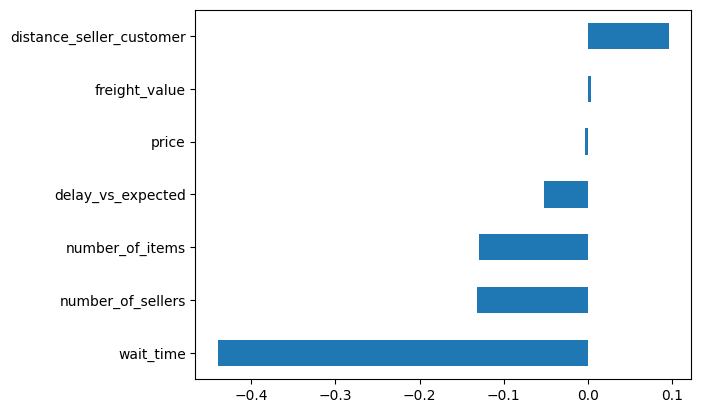

In [ ]:
model4.params[1:].sort_values().plot(kind='barh');

<details>\n    <summary>- 💡 Açıklamalar 💡 -</summary>\n\n- `wait_time` en açıklayıcı değişkendir\n- Bir siparişte daha fazla `items` ve `sellers` olduğunda `review_score` genellikle düşüyor gibi görünür\n- Mesafe (distance) da müşteri memnuniyetinde bir rol oynar\n- Seçtiğiniz özelliğe bağlı olarak, `price` ve `freight_value` hakkında p-değerleri yüksekse bir sonuç çıkaramayabilirsiniz\n\n- Genel olarak, bu çok değişkenli regresyon istatistiksel olarak anlamlı kalır; çünkü F-istatistiği 1'den çok daha büyüktür (en az bir özellik çok düşük p-değerine sahiptir)\n\n- R-kare çok fazla artmamıştır. `review_score`'un açıklanabilirliğinin çoğu orders veri setinin dışında yer alıyor.\n\n⚠️ Gözlem sayısı (n) özellik sayısından (p) çok daha yüksek olduğunda düşük R-kare yaygındır. Bu tür regresyonlardan anlamlı çıkarımlar elde edilebilir, yeter ki istatistiksel olarak anlamlı olsunlar.\n</details>

## 3 - Model performansını kontrol et

⚠️ Regresyon performansını yalnızca R-kare ile ölçmeyin!\n\n👀 Tahminlerin dağılımını ve özellikle artıkların (residuals) dağılımını her zaman görselleştirin.\n\n❓ Artıkları hesaplayın.\n\nDoğrusal regresyon yaparken artıkların ortalamasının 0 olduğunu görmelisiniz (bunu her zaman doğrulayın).

In [ ]:
predicted_review_score = model4.predict(orders_standardized)
residuals = predicted_review_score - orders_standardized.review_score

🧮 İlgili RMSE'yi hesaplayın.

In [ ]:
rmse = (residuals**2).mean()**0.5
rmse

1.1883154116821097

📊 `residuals`'ları bir histogram olarak görselleştirin.

Text(0.5, 1.0, 'residuals density plot')

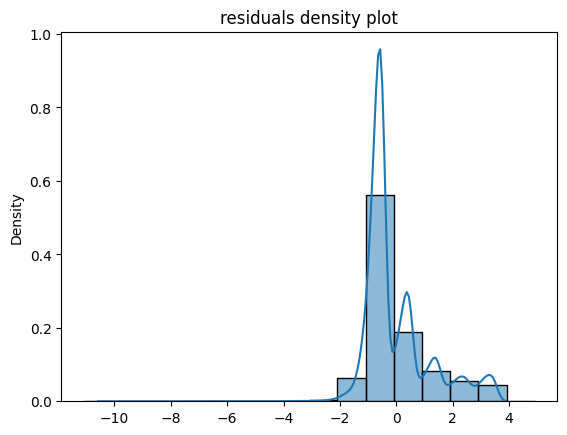

In [ ]:
sns.histplot(residuals, kde=True, stat='density', discrete=True)
plt.title('residuals density plot')

❓ Artık dağılımının bu kadar garip bir şekle sahip olmasının nedenini tahmin edebilir misiniz?\n\n*İpucu:*\n👉 Aynı grafikte hem `review_score` hem de `predicted_review_score` dağılımlarını çiziniz.

Text(0.5, 1.0, 'distribution of predicted and actual values')

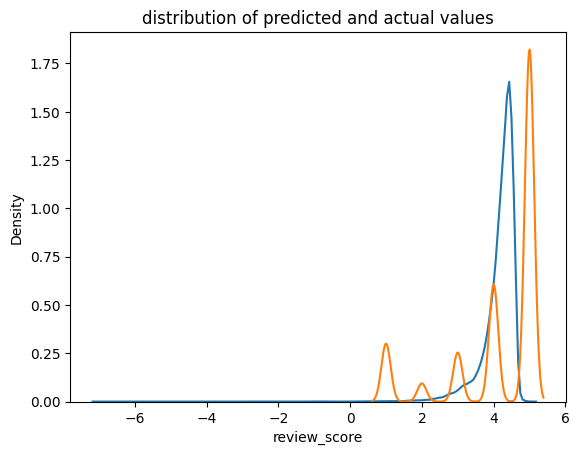

In [ ]:
sns.kdeplot(predicted_review_score, label='predicted review score')
sns.kdeplot(orders.review_score, label='actual review score')
plt.title('distribution of predicted and actual values')

📈 Aslında önceki görevde `review_score` ile `delay_vs_expected` arasındaki regresyon doğrusunu zaten çizmiştik.\n\nAşağıdaki hücreyi çalıştırarak o grafiği tekrar görselleştirin:

(0.0, 5.933374507580114)

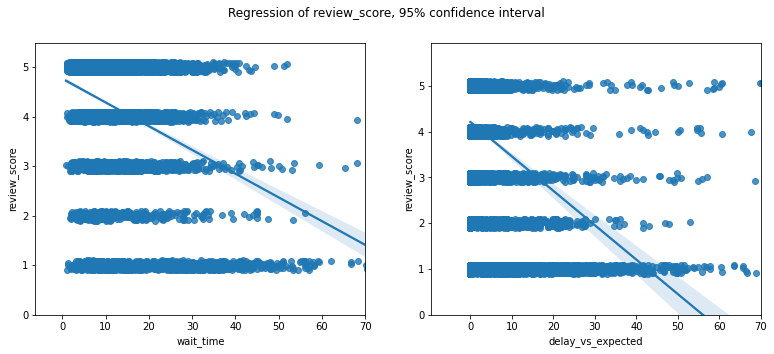

In [ ]:
sample = orders.sample(10000, random_state=42)
plt.figure(figsize=(13,5))
plt.suptitle('Regression of review_score, 95% confidence interval')
plt.subplot(1,2,1)
sns.regplot(x = sample.wait_time, y= sample.review_score, y_jitter=.1, ci=95)
plt.xlim(right=70)
plt.ylim(bottom=0)

plt.subplot(1,2,2)
sns.regplot(x = orders.delay_vs_expected, y= orders.review_score, y_jitter=.1, ci=95)
plt.xlim(right=70)
plt.ylim(bottom=0)

☝️ Görüldüğü gibi, bir siparişin `review_score`'unu `wait_time` veya `delay_vs_expected` ile regresyonla modellemek zor olabilir; çünkü `review_score` ayrık (discrete) bir sayı olup aynı zamanda kategorik olarak da yorumlanabilir: 1 (çok kötü), 2 (kötü), 3 (ortalama), 4 (iyi), 5 (mükemmel).

☝️ Sonuç olarak, modelimiz iki nedenle pek iyi sayılmaz:\n- Birincisi, `review_score`'ların anlamlı bir kısmını açıklayacak yeterli özelliğe sahip değiliz (düşük R-kare)\n- İkincisi, ayrık bir sınıflandırma problemini doğrusal bir regresyon ile modellemeye çalışıyoruz

💡 Bu nedenle, bireysel siparişler üzerinde çalışıp ayrık `review_score`'ları `wait_time` ile açıklamaya çalışmak yerine, bir sonraki görevde siparişleri satıcı bazında gruplayarak analizimizi satıcı düzeyinde odaklayacağız.

🏁 Harika iş!
💾 İşiniz bittiğinde bu notebook'u *kaydetmeyi*, *commit* etmeyi ve *push* etmeyi unutmayın!